In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取成员2给你的清洗后数据
df = pd.read_csv('clean_citibike.csv')  # 文件名以成员2实际给的为准

# 看一眼数据长什么样
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ride_duration  200000 non-null  float64
 1   start_time     200000 non-null  object 
 2   end_time       200000 non-null  object 
 3   start_station  199872 non-null  object 
 4   end_station    199445 non-null  object 
 5   start_lat      199872 non-null  float64
 6   start_lng      199872 non-null  float64
 7   end_lat        199413 non-null  float64
 8   end_lng        199413 non-null  float64
 9   user_type      200000 non-null  object 
 10  bikeid         200000 non-null  object 
 11  rideable_type  200000 non-null  object 
 12  start_date     200000 non-null  object 
 13  hour           200000 non-null  int64  
 14  weekday        200000 non-null  int64  
 15  is_weekend     200000 non-null  int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 24.4+ MB


In [4]:
# ========================================
# 成员3 - 完整分析代码
# 数据已成功读取，变量名为 df
# ========================================

# 1. 先过滤异常值（骑行时长少于60秒可能是故障车）
df_clean = df[df['ride_duration'] >= 60].copy()
print(f"过滤前：{len(df)} 条，过滤后：{len(df_clean)} 条")

# ========================================
# 任务一：描述性统计量
# ========================================

# 1.1 骑行时长统计
duration_mean = df_clean['ride_duration'].mean()
duration_median = df_clean['ride_duration'].median()
duration_max = df_clean['ride_duration'].max()
duration_min = df_clean['ride_duration'].min()

print("\n" + "="*40)
print("【骑行时长统计】")
print("="*40)
print(f"平均时长：{duration_mean:.1f} 秒（{duration_mean/60:.1f} 分钟）")
print(f"中位数：{duration_median:.1f} 秒（{duration_median/60:.1f} 分钟）")
print(f"最长：{duration_max:.1f} 秒（{duration_max/60:.1f} 分钟）")
print(f"最短：{duration_min:.1f} 秒（{duration_min/60:.1f} 分钟）")

# 1.2 用户占比
user_counts = df_clean['user_type'].value_counts()
user_pct = df_clean['user_type'].value_counts(normalize=True) * 100

print("\n" + "="*40)
print("【用户类型占比】")
print("="*40)
for user, count in user_counts.items():
    pct = user_pct[user]
    print(f"{user}：{count:,} 人（{pct:.1f}%）")

# 1.3 工作日 vs 周末
weekday_rides = df_clean[df_clean['is_weekend'] == 0].shape[0]
weekend_rides = df_clean[df_clean['is_weekend'] == 1].shape[0]

print("\n" + "="*40)
print("【工作日 vs 周末】")
print("="*40)
print(f"工作日骑行量：{weekday_rides:,} 条")
print(f"周末骑行量：{weekend_rides:,} 条")
print(f"周末占比：{weekend_rides/(weekday_rides+weekend_rides)*100:.1f}%")

# 1.4 热门站点TOP10
top10_start = df_clean['start_station'].value_counts().head(10)
top10_end = df_clean['end_station'].value_counts().head(10)

print("\n" + "="*40)
print("【借车站点TOP10】")
print("="*40)
for i, (station, count) in enumerate(top10_start.items(), 1):
    print(f"{i}. {station}：{count:,} 次")

print("\n" + "="*40)
print("【还车站点TOP10】")
print("="*40)
for i, (station, count) in enumerate(top10_end.items(), 1):
    print(f"{i}. {station}：{count:,} 次")

# 1.5 早晚高峰
hourly_counts = df_clean['hour'].value_counts().sort_index()

print("\n" + "="*40)
print("【高峰时段TOP5】")
print("="*40)
hourly_sorted = hourly_counts.sort_values(ascending=False)
for hour, count in hourly_sorted.head(5).items():
    print(f"  {hour:02d}:00 - {count:,} 次")

# 1.6 月度趋势
monthly_counts = df_clean['start_date'].str[:7].value_counts().sort_index()
print("\n" + "="*40)
print("【月度骑行趋势】")
print("="*40)
for month, count in monthly_counts.items():
    print(f"{month}：{count:,} 次")

# ========================================
# 任务二：保存结果到CSV
# ========================================

# 保存统计结果
stats_summary = pd.DataFrame({
    '指标': ['总骑行次数', '平均时长(分钟)', '中位数时长(分钟)', 
             '会员占比(%)', '临时用户占比(%)', '工作日骑行量', '周末骑行量'],
    '数值': [len(df_clean), duration_mean/60, duration_median/60,
             user_pct.get('Subscriber', 0), user_pct.get('Customer', 0),
             weekday_rides, weekend_rides]
})
stats_summary.to_csv('统计结果汇总表.csv', index=False)
print("\n✅ 已保存：统计结果汇总表.csv")

# 保存热门站点
top10_start.to_csv('热门借车站点.csv')
top10_end.to_csv('热门还车站点.csv')
print("✅ 已保存：热门借车站点.csv、热门还车站点.csv")

# 保存小时趋势
hourly_counts.to_csv('每小时骑行量.csv')
print("✅ 已保存：每小时骑行量.csv")

# 保存月度趋势
monthly_counts.to_csv('月度骑行趋势.csv')
print("✅ 已保存：月度骑行趋势.csv")

# ========================================
# 任务三：给成员4的数据
# ========================================

# 3.1 站点特征表（聚类用）
station_features = df_clean.groupby('start_station').agg({
    'ride_duration': 'mean',
    'start_station': 'count'
}).rename(columns={'start_station': 'total_trips', 'ride_duration': 'avg_duration'})
station_features = station_features.reset_index()
station_features.columns = ['station_name', 'avg_duration', 'total_trips']
station_features.to_csv('station_features.csv', index=False)
print("✅ 已保存：station_features.csv（给成员4聚类用）")

# 3.2 日骑行量时间序列（预测用）
df_clean['date'] = pd.to_datetime(df_clean['start_time']).dt.date
daily_rides = df_clean.groupby('date').size().reset_index()
daily_rides.columns = ['date', 'daily_rides']
daily_rides.to_csv('daily_rides.csv', index=False)
print("✅ 已保存：daily_rides.csv（给成员4预测用）")

print("\n" + "="*40)
print("🎉 所有分析完成！")
print("="*40)

过滤前：200000 条，过滤后：200000 条

【骑行时长统计】
平均时长：800.8 秒（13.3 分钟）
中位数：569.1 秒（9.5 分钟）
最长：78982.1 秒（1316.4 分钟）
最短：60.1 秒（1.0 分钟）

【用户类型占比】
Subscriber：158,994 人（79.5%）
Customer：41,006 人（20.5%）

【工作日 vs 周末】
工作日骑行量：151,400 条
周末骑行量：48,600 条
周末占比：24.3%

【借车站点TOP10】
1. Pier 61 at Chelsea Piers：755 次
2. W 21 St & 6 Ave：691 次
3. Cooper Square & Astor Pl：664 次
4. 9 Ave & W 33 St：627 次
5. Broadway & E 14 St：611 次
6. W 31 St & 7 Ave：608 次
7. Central Park S & 6 Ave：600 次
8. E 17 St & Broadway：584 次
9. Broadway & W 58 St：575 次
10. University Pl & E 14 St：554 次

【还车站点TOP10】
1. Pier 61 at Chelsea Piers：776 次
2. W 21 St & 6 Ave：638 次
3. Cooper Square & Astor Pl：624 次
4. W 31 St & 7 Ave：594 次
5. Central Park S & 6 Ave：590 次
6. 7 Ave & Central Park South：583 次
7. Broadway & E 14 St：582 次
8. 9 Ave & W 33 St：572 次
9. E 17 St & Broadway：551 次
10. Broadway & W 58 St：548 次

【高峰时段TOP5】
  18:00 - 17,328 次
  17:00 - 17,239 次
  19:00 - 14,662 次
  16:00 - 13,646 次
  08:00 - 12,332 次

【月度骑行趋势】
2026-06：39 次
2026-07：199,961 

开始生成五张初版图...

正在生成 图1_骑行时长箱线图.png ...


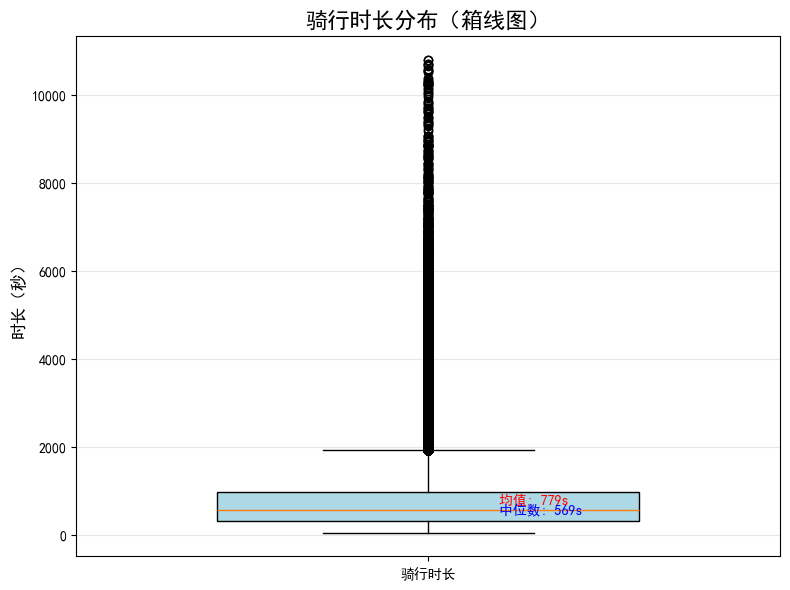

✅ 图1_骑行时长箱线图.png 已保存

正在生成 图2_热门借车站点.png ...


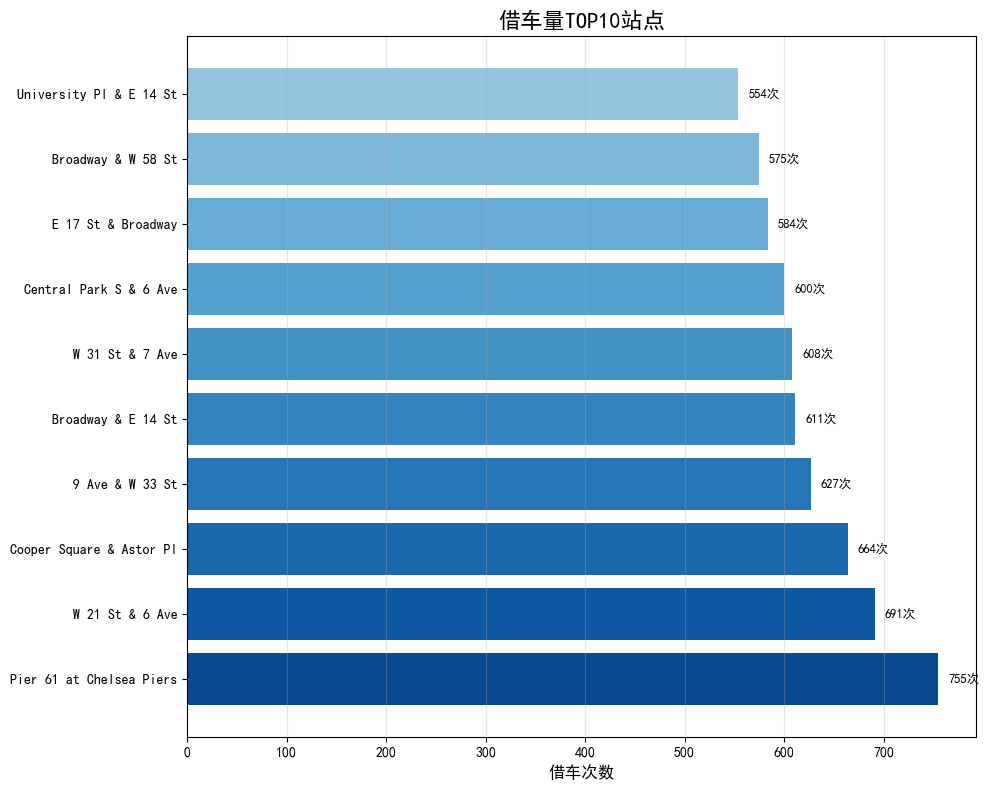

✅ 图2_热门借车站点.png 已保存

正在生成 图3_用户占比.png ...


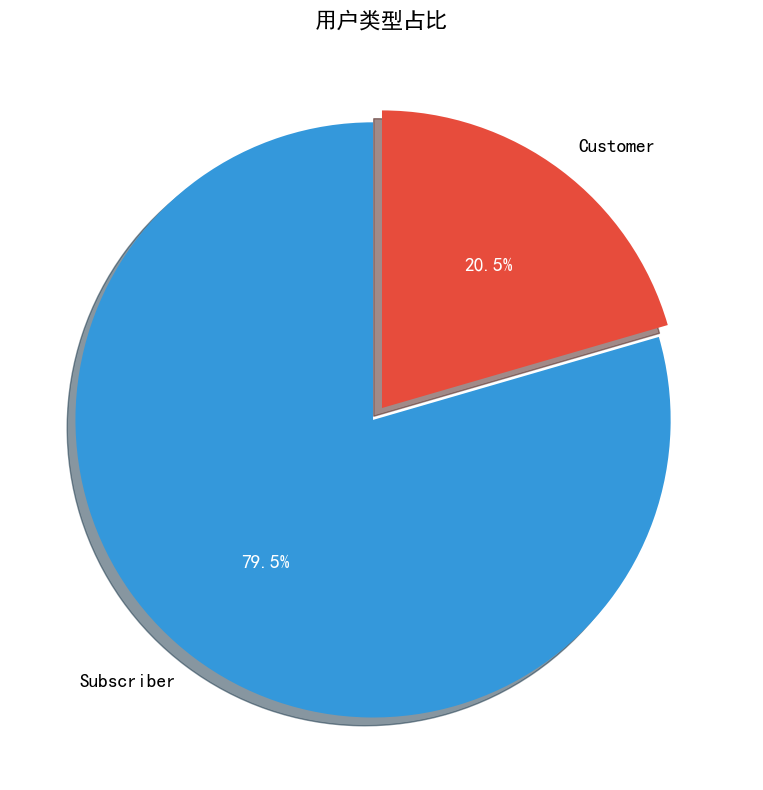

✅ 图3_用户占比.png 已保存

正在生成 图4_工作日vs周末小时趋势.png ...


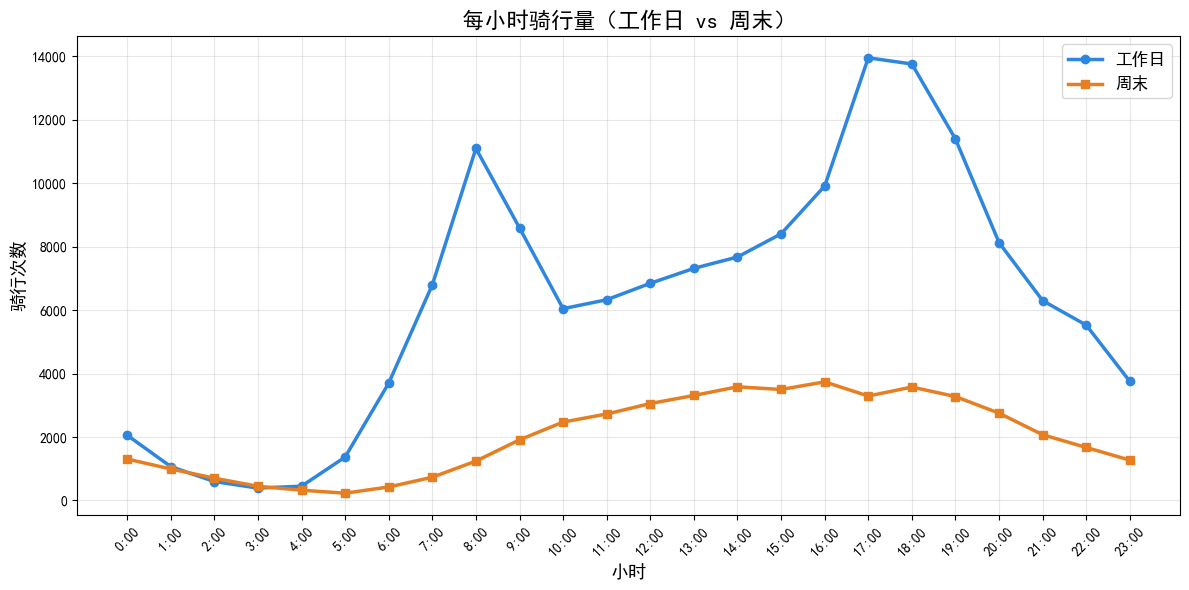

✅ 图4_工作日vs周末小时趋势.png 已保存

正在生成 图5_月度趋势.png ...


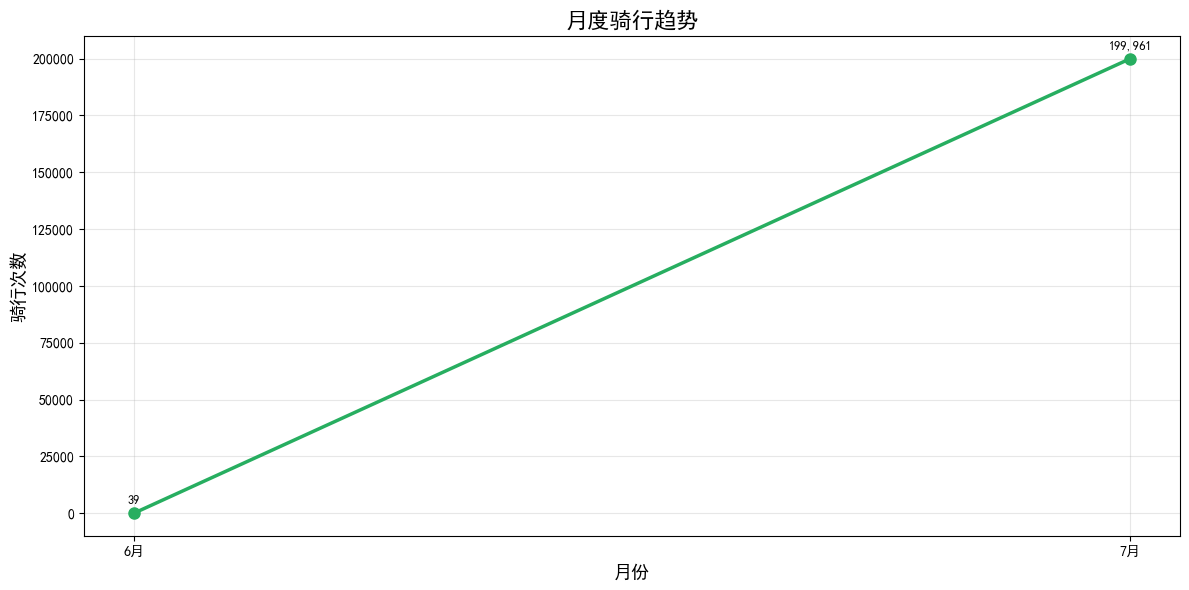

✅ 图5_月度趋势.png 已保存


正在保存5张图背后的聚合数据...
✅ 所有5张图的聚合数据已保存

🎉 五张初版图全部生成完成！
📁 已保存：5张 .png 图片 + 5个 .csv 数据文件


In [5]:
# ========================================
# 五张初版图（成员3画图代码）
# 数据已加载在 df 中
# ========================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 设置中文字体（避免中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 先过滤异常值（和之前保持一致）
df_clean = df[df['ride_duration'] >= 60].copy()

print("开始生成五张初版图...\n")

# ========================================
# 图1：骑行时长箱线图
# ========================================
print("正在生成 图1_骑行时长箱线图.png ...")

plt.figure(figsize=(8, 6))
# 过滤掉3小时(10800秒)以上的极端值让图更清晰
data_plot = df_clean[df_clean['ride_duration'] <= 10800]['ride_duration']
box = plt.boxplot(data_plot, patch_artist=True, widths=0.6)
box['boxes'][0].set_facecolor('lightblue')
plt.title('骑行时长分布（箱线图）', fontsize=16, fontweight='bold')
plt.ylabel('时长（秒）', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks([1], ['骑行时长'])
# 添加均值标注
mean_val = data_plot.mean()
median_val = data_plot.median()
plt.text(1.1, mean_val, f'均值: {mean_val:.0f}s', va='center', color='red', fontsize=10)
plt.text(1.1, median_val, f'中位数: {median_val:.0f}s', va='center', color='blue', fontsize=10)
plt.tight_layout()
plt.savefig('图1_骑行时长箱线图.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 图1_骑行时长箱线图.png 已保存\n")

# ========================================
# 图2：借车TOP10站点（水平柱状图）
# ========================================
print("正在生成 图2_热门借车站点.png ...")

top10 = df_clean['start_station'].value_counts().head(10)
plt.figure(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top10)))[::-1]
bars = plt.barh(top10.index, top10.values, color=colors)
plt.title('借车量TOP10站点', fontsize=16, fontweight='bold')
plt.xlabel('借车次数', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
# 在柱子上添加数值标签
for bar, val in zip(bars, top10.values):
    plt.text(val + 10, bar.get_y() + bar.get_height()/2, 
             f'{val}次', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('图2_热门借车站点.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 图2_热门借车站点.png 已保存\n")

# ========================================
# 图3：用户类型占比（饼图）
# ========================================
print("正在生成 图3_用户占比.png ...")

user_counts = df_clean['user_type'].value_counts()
plt.figure(figsize=(8, 8))
colors_pie = ['#3498db', '#e74c3c']
explode = (0.05, 0)
wedges, texts, autotexts = plt.pie(
    user_counts.values, 
    labels=user_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=colors_pie,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 14}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title('用户类型占比', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('图3_用户占比.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 图3_用户占比.png 已保存\n")

# ========================================
# 图4：工作日vs周末每小时骑行量（折线图）
# ========================================
print("正在生成 图4_工作日vs周末小时趋势.png ...")

hourly_weekday = df_clean[df_clean['is_weekend'] == 0]['hour'].value_counts().sort_index()
hourly_weekend = df_clean[df_clean['is_weekend'] == 1]['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(hourly_weekday.index, hourly_weekday.values, 
         label='工作日', marker='o', linewidth=2.5, markersize=6, color='#2e86de')
plt.plot(hourly_weekend.index, hourly_weekend.values, 
         label='周末', marker='s', linewidth=2.5, markersize=6, color='#e67e22')
plt.xlabel('小时', fontsize=13)
plt.ylabel('骑行次数', fontsize=13)
plt.title('每小时骑行量（工作日 vs 周末）', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24), [f'{i}:00' for i in range(24)], rotation=45)
plt.tight_layout()
plt.savefig('图4_工作日vs周末小时趋势.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 图4_工作日vs周末小时趋势.png 已保存\n")

# ========================================
# 图5：月度骑行趋势（折线图）
# ========================================
print("正在生成 图5_月度趋势.png ...")

# 从 start_time 提取月份
df_clean['month'] = pd.to_datetime(df_clean['start_time']).dt.month
monthly_counts = df_clean['month'].value_counts().sort_index()

month_names = ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月']

plt.figure(figsize=(12, 6))
plt.plot(monthly_counts.index, monthly_counts.values, 
         marker='o', linewidth=2.5, markersize=8, color='#27ae60')
plt.xlabel('月份', fontsize=13)
plt.ylabel('骑行次数', fontsize=13)
plt.title('月度骑行趋势', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(monthly_counts.index, [month_names[i-1] for i in monthly_counts.index])
# 在数据点上添加数值标签
for x, y in zip(monthly_counts.index, monthly_counts.values):
    plt.text(x, y + 3000, f'{y:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('图5_月度趋势.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 图5_月度趋势.png 已保存\n")

# ========================================
# 保存5张图背后的聚合数据
# ========================================
print("\n正在保存5张图背后的聚合数据...")

# 图1数据
data_plot.to_csv('图1_骑行时长数据.csv', index=False)

# 图2数据
top10.to_csv('图2_热门借车站点数据.csv', header=['借车次数'])

# 图3数据
user_counts.to_csv('图3_用户占比数据.csv', header=['用户数量'])

# 图4数据
hourly_comparison = pd.DataFrame({
    '小时': hourly_weekday.index,
    '工作日骑行量': hourly_weekday.values,
    '周末骑行量': hourly_weekend.values
})
hourly_comparison.to_csv('图4_小时对比数据.csv', index=False)

# 图5数据
monthly_counts.to_csv('图5_月度趋势数据.csv', header=['骑行次数'])

print("✅ 所有5张图的聚合数据已保存")

print("\n" + "="*50)
print("🎉 五张初版图全部生成完成！")
print("📁 已保存：5张 .png 图片 + 5个 .csv 数据文件")
print("="*50)